In [1]:
from generate_utils import load_GraphModel, load_BiLSTMModel
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

/home/maximos/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [3]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/graph/graph_model.pt'
bilstm_model_path = 'saved_models/bilstm/bilstm_model.pt'

In [4]:
graph_model = load_GraphModel(graph_model_path, device)
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)

In [5]:
graph_model.eval()
bilstm_model.eval()

HarmonyBiLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [6]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

In [7]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt
loading nott


In [8]:
graph_embeddings = []
bilstm_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # bilstm
            g.make_bilstm_seq_of_segment(bar_start, bar_end)
            segment_bilstm = g.segment_bilstm.unsqueeze(0)
            lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            bilstm_embeddings.append(
                z_bilstm.detach().cpu().numpy()
            )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
bilstm_embeddings = np.vstack(bilstm_embeddings)

28it [00:00, 67.63it/s]
45it [00:00, 60.53it/s]


In [9]:
print(graph_embeddings.shape)
print(bilstm_embeddings.shape)

(1054, 128)
(1054, 128)


In [10]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [11]:
# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@2_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@2m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]'

# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
# in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@2;C:maj_@2'
# in_seq_2 = 'b_G:9_@2;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@2;C:maj_@2'
# in_seq_4 = 'b_C#:7_@2;C:maj_@2'

# in_seq_1 = 'b_C:7_@2;F:maj_@2'
# in_seq_2 = 'b_C:9_@2;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@2;F:maj_@2'
# in_seq_4 = 'b_F#:7_@2;F:maj_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_C:7_@2;F:maj7_@2'
# in_seq_3 = 'b_F:7_@2;A#:maj7_@2'
# in_seq_4 = 'b_A#:7_@2;D#:maj7_@2'

# in_seq_1 = 'b_B:7_@2;E:maj7_@2'
# in_seq_2 = 'b_E:7_@2;A:maj7_@2'
# in_seq_3 = 'b_A:7_@2;D:maj7_@2'
# in_seq_4 = 'b_D:7_@2;G:maj7_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_G:7_@2;D:maj7_@2'
# in_seq_3 = 'b_G:7_@2;A:maj7_@2'
# in_seq_4 = 'b_A#:min11_@4b_A#:min11_@4'

in_seq_1 = 'b_D:7(b9)_@2;G:maj_@2'
in_seq_2 = 'b_D:9_@2;G:maj_@2'
in_seq_3 = 'b_F#:hdim7_@2;G:maj_@2'
in_seq_4 = 'b_G#:7_@2;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model)
y_graph_3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model)
y_graph_4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model)

y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model)
y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model)
y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model)
y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model)

D:7(b9) in vocab as: 90
G:maj in vocab as: 210
D:9 in vocab as: 81
G:maj in vocab as: 210
F#:hdim7 in vocab as: 194
G:maj in vocab as: 210
G#:7 in vocab as: 245
G:maj in vocab as: 210
D:7(b9) in vocab as: 90
G:maj in vocab as: 210
D:9 in vocab as: 81
G:maj in vocab as: 210
F#:hdim7 in vocab as: 194
G:maj in vocab as: 210
G#:7 in vocab as: 245
G:maj in vocab as: 210


In [12]:
from sklearn.decomposition import PCA

In [13]:
pca_graph = PCA(n_components=2)
pca_bilstm = PCA(n_components=2)

In [14]:
y_graph = pca_graph.fit_transform(graph_embeddings)
y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [15]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

new_bilstm = np.vstack([
    y_bilstm_1.detach().cpu().numpy(),
    y_bilstm_2.detach().cpu().numpy(),
    y_bilstm_3.detach().cpu().numpy(),
    y_bilstm_4.detach().cpu().numpy(),
])

new_graph_2d = pca_graph.transform(new_graph)
new_bilstm_2d = pca_bilstm.transform(new_bilstm)

In [16]:
# print(y_graph.shape, y_bilstm.shape)

In [17]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [18]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
datasets_list = [metadata[i]['dataset'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_graph,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords'],
)
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [19]:
# chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_bilstm,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords']
)
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [20]:
d = datasets['gjt']['dataset'][17]
d['graph_ready_object'].make_graph_of_segment(13,15)
d['graph_ready_object'].make_bilstm_seq_of_segment(13,15)

In [21]:
g = graph_from_string(in_seq_4)

G#:7 in vocab as: 245
G:maj in vocab as: 210


In [22]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [13, 15)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 14:
Bar token positions: [66, 67, 68, 69]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root: 10
Chord ID: 314
Bar Positions: [0, 1, 2, 3]
Token Positions: [66, 67, 68, 69]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.])
Bar 15:
Bar token positions: [71, 72, 73, 74]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root:

In [23]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [24]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [25]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].num_nodes, graph_string["event"].num_nodes)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
2 2
torch.Size([2, 12]) torch.Size([2, 7])


In [26]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_index shape differs: torch.Size([2, 12]) vs torch.Size([2, 7])", "('pitch', 'participates', 'event').edge_attr shape differs: torch.Size([12, 5]) vs torch.Size([7, 5])", "('event', 'next', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 0], [0, 1], [0, 2], [0, 3], [0, 4]]']


In [27]:
print(graph_dataset["event"].num_nodes)
print(graph_string["event"].num_nodes)

2
2


In [28]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[1., 1., 1., 0., 0., 0.]])
tensor([[0., 0., 0., 1., 1., 0.]])


In [29]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [30]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [31]:
import matplotlib.pyplot as plt

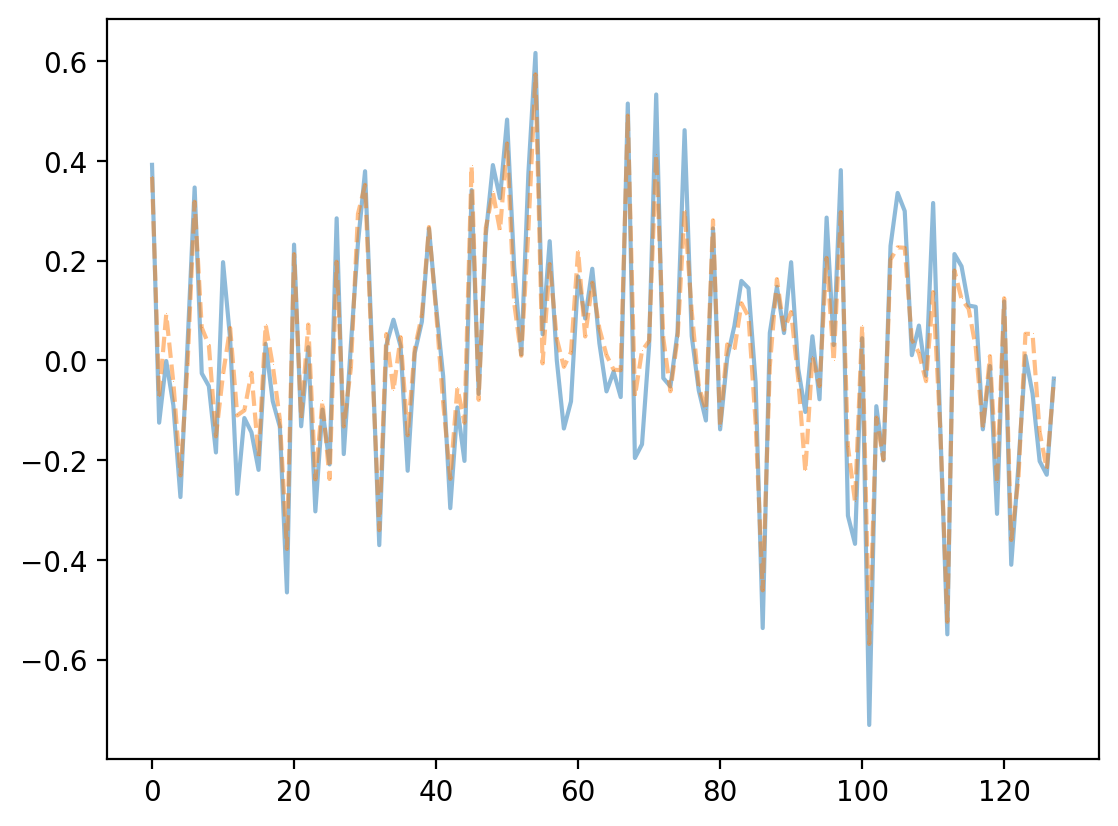

In [32]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

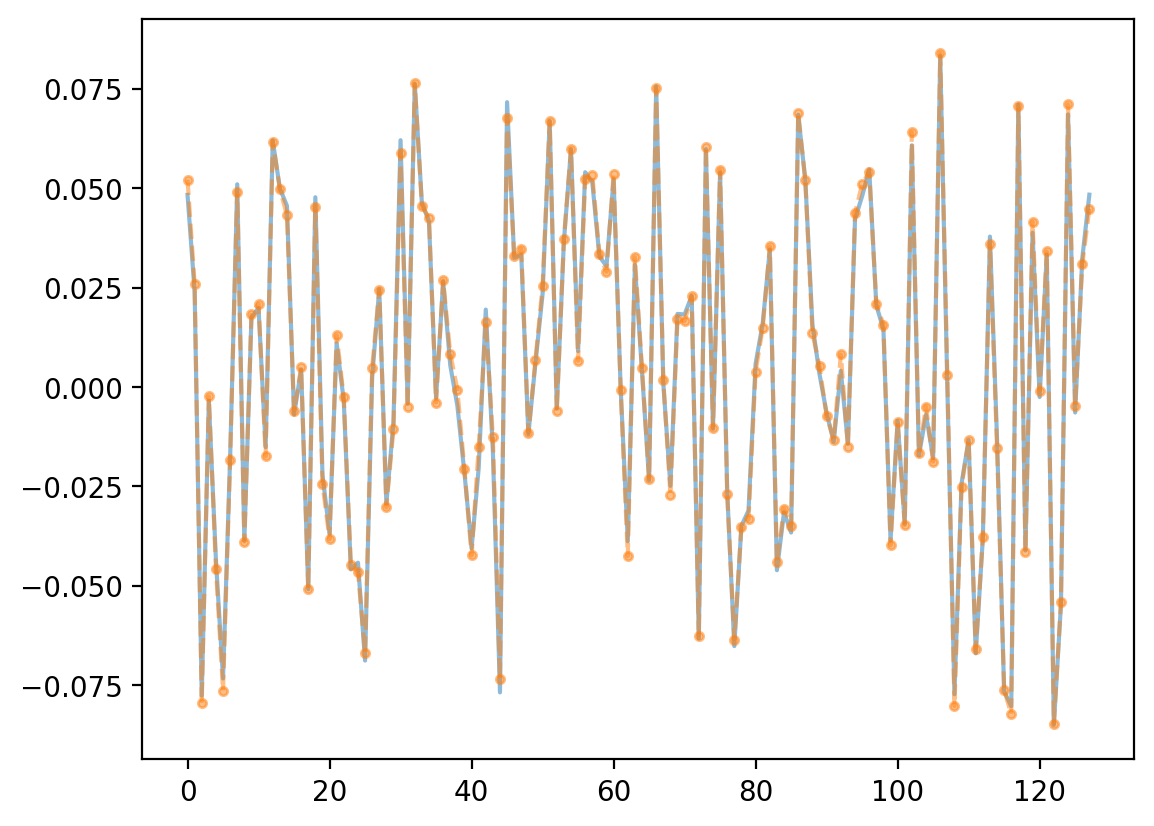

In [33]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [34]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([2, 12])
torch.Size([2, 12])


In [35]:
sorted_x_idxs = np.argsort(y_graph[:,0])
# sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

sorted_y_idxs = np.argsort(y_graph[:,1])
# sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[749 741 102 ... 235 236   6]
nott_22_[8, 10]<br>b_A:min_@1_m[0]<br>E:maj_@1_m[11]<br>A:min_@2_m[9, 2, 4]<br>b_A:min_@1_m[0]<br>E:maj_@1_m[11]<br>A:min_@2_m[0, 9, 4]<br>
gjt_0_[6, 8]<br>b_D:min9_@4_m[4]<br>b_G:13_@4_m[2, 4]<br>
[ 110 1022  507 ...  290  211  168]
gjt_8_[4, 6]<br>b_C:min_@4_m[0, 3, 7, 9, 11]<br>b_D#:9_@4_m[1, 3, 4, 7, 9]<br>
gjt_12_[6, 8]<br>b_E:maj7_@2_m[8, 1, 11]<br>F#:min7_@1_m[4]<br>B:sus4_@1_m[4]<br>b_E:maj6_@2_m[1]<br>F#:min7_@1_m[1]<br>B:7_@1_m[]<br>


In [36]:
graph_seqs = ''

# print left-most
print('left-most chord sequences:')
graph_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print right-most
print('right-most chord sequences:')
graph_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
graph_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
graph_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print top-most
print('top-most chord sequences:')
graph_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
A:min E:maj A:min  A:min E:maj A:min  
A:maj  A:maj  
D:min  D:maj A:min  
A:min  A:min E:maj A:min  
A:min  G:maj D:maj  
A:min E:maj A:min  D:min  
F:maj C:maj  A:min E:min  
A:min D:min  D:min  
G:maj D:maj  G:maj  
F:maj  G:maj E:maj  
C:maj F:maj  C:maj G:maj  
G:maj A:min  D:min C:maj  
A:min  A:min C:maj  
C:maj F:maj  C:maj F:maj  
A:min  G:maj A:min  
C:maj A:min  D:min G:maj  
C:maj  G:maj D:min  
G:maj D:min  G:maj  
F:maj  C:maj A:min  
C:maj D:min  G:maj C:maj  

right-most chord sequences:
D:min9  G:13  
A:min11  A:min11  
A:min11  A#:min11  
A#:min11  A#:min11  
E:min7  A:13  
G:13  C:maj7  
A:13  A:min7  
D:9  G#:7 G:13  
C:9  F:maj9  
E:7(b9)  F:9  
F:9  A#:9  
G#:7(b13)  G#:7(b13)  
G:9  G:9  
D:9  D:9  
D#:9  G:9  
A:9  A:9  
G:min7  C:9  
G:min7  C:7(#11)  
C:maj7  F:9  
E:min7  D:min9  

bottom-most chord sequences:
C:min  D#:9  
C:maj  C:maj  
D#:7  D:min7  
C:maj  G:7  
C:maj  A:7  
C:maj  A#:maj  
F:maj  C:maj  
C:maj  C:7  
C:maj  G:m

In [37]:
print(graph_seqs)

left-most chord sequences:
A:min E:maj A:min  A:min E:maj A:min  
A:maj  A:maj  
D:min  D:maj A:min  
A:min  A:min E:maj A:min  
A:min  G:maj D:maj  
A:min E:maj A:min  D:min  
F:maj C:maj  A:min E:min  
A:min D:min  D:min  
G:maj D:maj  G:maj  
F:maj  G:maj E:maj  
C:maj F:maj  C:maj G:maj  
G:maj A:min  D:min C:maj  
A:min  A:min C:maj  
C:maj F:maj  C:maj F:maj  
A:min  G:maj A:min  
C:maj A:min  D:min G:maj  
C:maj  G:maj D:min  
G:maj D:min  G:maj  
F:maj  C:maj A:min  
C:maj D:min  G:maj C:maj  

right-most chord sequences:
D:min9  G:13  
A:min11  A:min11  
A:min11  A#:min11  
A#:min11  A#:min11  
E:min7  A:13  
G:13  C:maj7  
A:13  A:min7  
D:9  G#:7 G:13  
C:9  F:maj9  
E:7(b9)  F:9  
F:9  A#:9  
G#:7(b13)  G#:7(b13)  
G:9  G:9  
D:9  D:9  
D#:9  G:9  
A:9  A:9  
G:min7  C:9  
G:min7  C:7(#11)  
C:maj7  F:9  
E:min7  D:min9  

bottom-most chord sequences:
C:min  D#:9  
C:maj  C:maj  
D#:7  D:min7  
C:maj  G:7  
C:maj  A:7  
C:maj  A#:maj  
F:maj  C:maj  
C:maj  C:7  
C:maj  G:m

In [38]:
# sorted_x_idxs = np.argsort(y_graph[:,0])
sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

# sorted_y_idxs = np.argsort(y_graph[:,1])
sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[102 197 198 ... 210 350 211]
gjt_7_[10, 12]<br>b_A:maj_@4_m[9]<br>b_A:maj_@4_m[0, 9, 2]<br>
gjt_15_[7, 9]<br>b_A:min7_@1_m[0]<br>D:7_@1_m[0]<br>G:min7_@1_m[0]<br>C:7_@1_m[0]<br>b_F:maj6_@2_m[5]<br>B:hdim7_@1_m[5]<br>E:7_@1_m[4]<br>
[884 885 886 ... 748 749 741]
nott_33_[3, 5]<br>b_G:7_@4_m[11, 7]<br>b_G:7_@4_m[2, 4, 5, 7]<br>
nott_22_[0, 2]<br>b_A:min_@1_m[0]<br>E:maj_@1_m[11]<br>A:min_@2_m[9, 2, 4]<br>b_A:min_@1_m[0]<br>E:maj_@1_m[11]<br>A:min_@2_m[0, 9, 4]<br>


In [39]:
bilstm_seqs = ''

# print left-most
print('left-most chord sequences:')
bilstm_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print right-most
print('right-most chord sequences:')
bilstm_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
bilstm_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
bilstm_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print top-most
print('top-most chord sequences:')
bilstm_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
A:maj  A:maj  
F#:7  A:maj6  
A:maj6  A:maj6  
C#:min7  F#:7  
A:maj  A:min  
A#:maj7  F#:sus4  
F#:sus4  F#:hdim7  
A:maj7  A#:maj7  
F#:hdim7  E:sus4  
F#:hdim7  B:7  
A:min  A:min  
E:maj  C#:min7  
A:min6  A:min6  
E:maj  E:maj  
F:maj7  F#:sus4  
A:min7  E:sus4  
F#:hdim7  B:7(b9)  
A#:maj7  A#:maj7  
A:maj6  F:maj7  
C:7(#11)  B:7  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj G:7 C:maj  C:maj F:maj  
A:min7 D:7  G:maj7 D:min7 G:7  
C:maj F:maj  C:maj G:7 C:maj  
A:7 D:7  G:7 C:maj7 E:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
G:min7 C:7 C#:dim  D:min7 G:7  
G:maj G:7  G:7 C:maj  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
G:maj G:7  C:maj G:7  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
F:maj7 D:min7  G:min7 C:7 C#:dim  
C:maj G:7  C:maj G:7  
E:min7 D#:7  G#:maj7 G:7  
D:7 G:7  C:maj G:7  
G:7 

In [40]:
print(bilstm_seqs)

left-most chord sequences:
A:maj  A:maj  
F#:7  A:maj6  
A:maj6  A:maj6  
C#:min7  F#:7  
A:maj  A:min  
A#:maj7  F#:sus4  
F#:sus4  F#:hdim7  
A:maj7  A#:maj7  
F#:hdim7  E:sus4  
F#:hdim7  B:7  
A:min  A:min  
E:maj  C#:min7  
A:min6  A:min6  
E:maj  E:maj  
F:maj7  F#:sus4  
A:min7  E:sus4  
F#:hdim7  B:7(b9)  
A#:maj7  A#:maj7  
A:maj6  F:maj7  
C:7(#11)  B:7  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj G:7 C:maj  C:maj F:maj  
A:min7 D:7  G:maj7 D:min7 G:7  
C:maj F:maj  C:maj G:7 C:maj  
A:7 D:7  G:7 C:maj7 E:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
G:min7 C:7 C#:dim  D:min7 G:7  
G:maj G:7  G:7 C:maj  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
G:maj G:7  C:maj G:7  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
F:maj7 D:min7  G:min7 C:7 C#:dim  
C:maj G:7  C:maj G:7  
E:min7 D#:7  G#:maj7 G:7  
D:7 G:7  C:maj G:7  
G:7 

In [41]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': 'Can you commend on sequences of musical chords? \
        For example, which chord sequence is more common: a) G:7 C:maj7 or b)C#:7 C:maj7?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
# print(response.message.content)

Both chord sequences can be considered equally valid and commonly used in various genres of music. However, it's important to note that the choice between these sequences often depends on the specific musical context, mood, and key signature.

1) **G:7 (Dominant 7th Chord):**
   - This chord is commonly used as a dominant chord, which naturally resolves to the tonic (C major). In a key of G, it creates a strong sense of tension that is often resolved when transitioning to C major.
   - It’s also known as "the most useful" or "the most important" chord in any key, as it has many harmonic uses and can create interesting melodic movement.

2) **C#:7 (Dominant 7th Chord):**
   - This is another dominant 7th chord, but this time leading to C major. It’s essentially the same progression as G:7 but starting a fifth higher.
   - The change of scale degree can provide a different feel or mood in a piece of music. For instance, if you are using modal interchange or parallel minor, it can create 

In [42]:
response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': f'You are a music harmony expert and you role is to provide \
    comments on chord progressions that appear within two PCA-projected spaces. \
    These PCA spaces were produced by two models that process symbolic music \
    harmony and we are interested in explaining whether there is something \
    specific that the first two axes represent (left-right and bottom-top). \
    These spaces were formed by the same short chord sequences and we only use \
    the ones on the extreme edges in the analysis.\
    We are interested in understanding if Model 1 or Model 2 \
    have generated more musically meaningful representations and which one is better. \
    Keep in mid that both Models are trained on pieces in C major and A minor \
    and that the sequences they processes are segments of C major - A minor pieces. \
    Below are the Sets positioned in the respective PCA spaces by each model. \
    Here is Set 1: `{bilstm_seqs}`. \n\n \
    Here is Set 2: `{graph_seqs}`.\n \
    If you had to pick a model, who would that be and why?',
  },
])
print(response['message']['content'])

To choose between Model 1 and Model 2 based on the PCA-projected spaces provided, let's analyze each set of chord sequences in detail. The goal is to evaluate which model better represents musically meaningful structures within those segments.

### Analysis:

**Set 1:**

- **Left-most Chord Sequences:**
  - These are mainly diatonic and tonic chords like `A:maj`, `F#:7`, etc., suggesting that the left-most axis could represent diatonic and tonic progressions.
  - The right-most extreme could then be more complex, showing chromatic and non-diatonic movements.

- **Right-most Chord Sequences:**
  - Contains more extended chords like `A:maj7`, `F#:sus4`, `F#:hdim7`, etc., indicating a focus on harmony and chord expansion beyond the traditional diatonic framework.
  
- **Bottom-most Chord Sequences:**
  - These involve simpler progressions, such as repetitive tonic chords (`G:7`) and minor chords (`A:min`).
  - Could represent stable harmonic structures.

- **Top-most Chord Sequences:**
  